# Fig6 — Group-mean VRMSE under four surface conditions

Compute the mean 10 m wind-vector RMSE for five weather-station groups during the six-hour closest-approach windows of Ragasa and Yagi. Each storm uses its own station classification from `input/20260616-两次台风站点分类.md` and is exported as a separate four-case grouped bar chart.

All runtime inputs are self-contained under `Fig6/input`; figures and numeric CSV results are written to `Fig6/output`.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display


def find_fig6_dir() -> Path:
    """Locate Fig6 when the notebook starts from Fig6 or the workspace root."""
    cwd = Path.cwd().resolve()
    marker = Path("input") / "20260616-两次台风站点分类.md"
    for candidate in (cwd, *cwd.parents):
        if (candidate / marker).is_file():
            return candidate
        if (candidate / "Fig6" / marker).is_file():
            return candidate / "Fig6"
    raise FileNotFoundError(f"Could not locate Fig6/input from {cwd}")


FIG6_DIR = find_fig6_dir()
INPUT_DIR = FIG6_DIR / "input"
OUTPUT_DIR = FIG6_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GROUP_MD = INPUT_DIR / "20260616-两次台风站点分类.md"

TS_COL = "timestamp_utc"
TS_FORMAT = "%Y%m%d %H%M"
EXPECTED_MINUTES = 6 * 60 + 1
LEAD = "24h"
DPI = 600

STORMS = {
    "ragasa": {
        "label": "Ragasa",
        "heading": "台风桦加沙站点分类：",
        "start": pd.Timestamp("2025-09-23 19:00", tz="UTC"),
        "end": pd.Timestamp("2025-09-24 01:00", tz="UTC"),
        "group_sizes": [5, 4, 4, 6, 4],
    },
    "yagi": {
        "label": "Yagi",
        "heading": "台风摩羯站点分类：",
        "start": pd.Timestamp("2024-09-05 09:00", tz="UTC"),
        "end": pd.Timestamp("2024-09-05 15:00", tz="UTC"),
        "group_sizes": [5, 3, 4, 7, 4],
    },
}

CASE_ORDER = ["no_lcz_no_srtm", "no_srtm", "no_lcz", "lcz_srtm"]
CASE_META = {
    "no_lcz_no_srtm": {"label": "Low terrain\nLow LCZ", "color": "#9E9E9E"},
    "no_srtm": {"label": "Low terrain\nHigh LCZ", "color": "#66A182"},
    "no_lcz": {"label": "High terrain\nLow LCZ", "color": "#6E8BC3"},
    "lcz_srtm": {"label": "High terrain\nHigh LCZ", "color": "#C96A5A"},
}

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
FONT_FAMILY = "Arial" if "Arial" in available_fonts else "DejaVu Sans"
mpl.rcParams.update({"font.family": FONT_FAMILY, "font.sans-serif": [FONT_FAMILY], "font.size": 16})

print("[Paths] Input :", INPUT_DIR)
print("[Paths] Output:", OUTPUT_DIR)
print("[Cases]", ", ".join(CASE_ORDER))
print("[Font]", FONT_FAMILY)

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Administrator\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


[Paths] Input : E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\input
[Paths] Output: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output
[Cases] no_lcz_no_srtm, no_srtm, no_lcz, lcz_srtm
[Font] Arial


In [2]:
def save_tiff(fig: mpl.figure.Figure, path: Path) -> None:
    """Save a publication-resolution TIFF, using LZW when supported."""
    try:
        fig.savefig(path, dpi=DPI, format="tiff", bbox_inches="tight", pil_kwargs={"compression": "tiff_lzw"})
    except TypeError:
        fig.savefig(path, dpi=DPI, format="tiff", bbox_inches="tight")


def read_station_csv(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Missing station time series: {path}")
    frame = pd.read_csv(path, dtype={TS_COL: str})
    if TS_COL not in frame.columns:
        raise ValueError(f"Missing {TS_COL!r} in {path}")
    rename = {column: str(column).strip().lower() for column in frame.columns if column != TS_COL}
    if len(rename.values()) != len(set(rename.values())):
        raise ValueError(f"Duplicate station columns after normalization in {path}")
    frame = frame.rename(columns=rename)
    frame[TS_COL] = pd.to_datetime(frame[TS_COL].astype(str).str.strip(), format=TS_FORMAT, utc=True, errors="raise")
    if frame[TS_COL].duplicated().any():
        raise ValueError(f"Duplicate timestamps in {path}")
    return frame.sort_values(TS_COL).reset_index(drop=True)


def subset_window(frame: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp, stations: list[str], source: Path) -> pd.DataFrame:
    missing_stations = sorted(set(stations) - set(frame.columns))
    if missing_stations:
        raise ValueError(f"Missing classified stations in {source}: {missing_stations}")
    data = frame.loc[frame[TS_COL].between(start, end), [TS_COL, *stations]].set_index(TS_COL)
    if len(data) != EXPECTED_MINUTES:
        raise RuntimeError(f"Expected {EXPECTED_MINUTES} records in {source.name} from {start} to {end}; found {len(data)}")
    return data.apply(pd.to_numeric, errors="coerce")


def english_group_label(group_name: str) -> str:
    if "城市中心" in group_name:
        return "Urban"
    if "内陆" in group_name:
        return "Plain"
    if "海边" in group_name:
        return "Coastal"
    if "海岛" in group_name:
        return "Island"
    if "山地" in group_name or "森林" in group_name:
        return "Mountainous"
    raise ValueError(f"Unknown station group: {group_name}")


def parse_station_groups(markdown: str, heading: str, expected_sizes: list[int]) -> dict[str, list[str]]:
    heading_match = re.search(rf"^{re.escape(heading)}\s*$", markdown, flags=re.MULTILINE)
    if heading_match is None:
        raise ValueError(f"Cannot find classification heading: {heading}")
    section_start = heading_match.end()
    next_heading = re.search(r"^(?:台风.+站点分类：|两次台风时间共同保留的站点分类：)\s*$", markdown[section_start:], flags=re.MULTILINE)
    section_end = section_start + next_heading.start() if next_heading else len(markdown)
    section = markdown[section_start:section_end]

    parsed: list[tuple[int, str, list[str]]] = []
    for line in section.splitlines():
        match = re.match(r"^\s*(\d+)\.\s*(.+?)[：:]\s*(.+?)；?\s*$", line)
        if match is None:
            continue
        codes: list[str] = []
        for item in re.split(r"[，,、]", match.group(3)):
            code_match = re.search(r"([A-Za-z0-9]+)\s*$", item.strip())
            if code_match:
                codes.append(code_match.group(1).lower())
        parsed.append((int(match.group(1)), match.group(2).strip(), codes))

    parsed.sort(key=lambda item: item[0])
    groups = {name: codes for _, name, codes in parsed}
    sizes = [len(codes) for codes in groups.values()]
    all_codes = [code for codes in groups.values() for code in codes]
    if len(groups) != 5 or sizes != expected_sizes:
        raise RuntimeError(f"Unexpected groups for {heading}: sizes={sizes}, expected={expected_sizes}")
    if len(all_codes) != 23 or len(set(all_codes)) != 23:
        raise RuntimeError(f"Expected 23 unique classified stations for {heading}")
    return groups


def load_observed_uv(storm_key: str, start: pd.Timestamp, end: pd.Timestamp, stations: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    storm_dir = INPUT_DIR / storm_key
    speed_path = storm_dir / "mean_wspd_obs.csv"
    direction_path = storm_dir / "mean_wdir_obs.csv"
    speed = subset_window(read_station_csv(speed_path), start, end, stations, speed_path)
    direction = subset_window(read_station_csv(direction_path), start, end, stations, direction_path)
    if not speed.index.equals(direction.index):
        raise RuntimeError(f"Observation speed/direction timestamps differ for {storm_key}")
    missing = speed.eq(32767) | direction.eq(32767) | (speed.eq(0.0) & direction.eq(0.0))
    speed = speed.mask(missing)
    direction = direction.mask(missing)
    theta = np.deg2rad(direction)
    return -speed * np.sin(theta), -speed * np.cos(theta)


def load_simulated_uv(storm_key: str, case_key: str, start: pd.Timestamp, end: pd.Timestamp, stations: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    storm_dir = INPUT_DIR / storm_key
    u_path = storm_dir / f"{case_key}_u_sim.csv"
    v_path = storm_dir / f"{case_key}_v_sim.csv"
    u = subset_window(read_station_csv(u_path), start, end, stations, u_path)
    v = subset_window(read_station_csv(v_path), start, end, stations, v_path)
    if not u.index.equals(v.index):
        raise RuntimeError(f"Simulation u/v timestamps differ for {storm_key} {case_key}")
    return u, v


def vector_rmse_by_station(obs_u: pd.DataFrame, obs_v: pd.DataFrame, sim_u: pd.DataFrame, sim_v: pd.DataFrame) -> pd.DataFrame:
    if not (obs_u.index.equals(obs_v.index) and obs_u.index.equals(sim_u.index) and obs_u.index.equals(sim_v.index)):
        raise RuntimeError("Observation and simulation timestamps are not identical")
    if not (list(obs_u.columns) == list(obs_v.columns) == list(sim_u.columns) == list(sim_v.columns)):
        raise RuntimeError("Observation and simulation station columns are not identical")
    squared_error = (sim_u - obs_u) ** 2 + (sim_v - obs_v) ** 2
    result = pd.DataFrame({"n_valid_minutes": squared_error.notna().sum(axis=0), "vrmse": np.sqrt(squared_error.mean(axis=0, skipna=True))})
    if (result["n_valid_minutes"] == 0).any() or not np.isfinite(result["vrmse"].to_numpy(dtype=float)).all():
        bad = result.index[(result["n_valid_minutes"] == 0) | ~np.isfinite(result["vrmse"].to_numpy(dtype=float))].tolist()
        raise RuntimeError(f"Invalid station VRMSE: {bad}")
    return result

In [3]:
classification_text = GROUP_MD.read_text(encoding="utf-8")
storm_results: dict[str, dict] = {}
generated_csvs: list[Path] = []

for storm_key, metadata in STORMS.items():
    groups = parse_station_groups(classification_text, metadata["heading"], metadata["group_sizes"])
    group_names_cn = list(groups)
    group_names_en = [english_group_label(name) for name in group_names_cn]
    group_en_by_cn = dict(zip(group_names_cn, group_names_en))
    group_by_station = {station: group for group, stations in groups.items() for station in stations}
    stations = [station for group_stations in groups.values() for station in group_stations]

    obs_u, obs_v = load_observed_uv(storm_key, metadata["start"], metadata["end"], stations)
    station_records: list[dict] = []
    for case_key in CASE_ORDER:
        sim_u, sim_v = load_simulated_uv(storm_key, case_key, metadata["start"], metadata["end"], stations)
        station_vrmse = vector_rmse_by_station(obs_u, obs_v, sim_u, sim_v)
        if len(station_vrmse) != 23:
            raise RuntimeError(f"Expected 23 station VRMSE values for {storm_key} {case_key}")
        for station, row in station_vrmse.iterrows():
            group_cn = group_by_station[station]
            station_records.append({
                "storm": metadata["label"],
                "case_key": case_key,
                "surface_case": CASE_META[case_key]["label"].replace("\n", " / "),
                "group_cn": group_cn,
                "group_en": group_en_by_cn[group_cn],
                "station": station.upper(),
                "n_valid_minutes": int(row["n_valid_minutes"]),
                "vrmse": float(row["vrmse"]),
            })

    station_df = pd.DataFrame(station_records)
    group_df = (station_df.groupby(["storm", "group_cn", "group_en", "case_key", "surface_case"], sort=False, as_index=False)["vrmse"]
                .agg(n_stations="count", mean_vrmse="mean"))
    group_order = {name: index for index, name in enumerate(group_names_en)}
    case_order = {case: index for index, case in enumerate(CASE_ORDER)}
    group_df["_group_order"] = group_df["group_en"].map(group_order)
    group_df["_case_order"] = group_df["case_key"].map(case_order)
    group_df = group_df.sort_values(["_group_order", "_case_order"]).drop(columns=["_group_order", "_case_order"]).reset_index(drop=True)

    expected_counts = dict(zip(group_names_en, metadata["group_sizes"]))
    for group_name, expected_count in expected_counts.items():
        observed_counts = group_df.loc[group_df["group_en"] == group_name, "n_stations"]
        if len(observed_counts) != 4 or not observed_counts.eq(expected_count).all():
            raise RuntimeError(f"Unexpected group count for {storm_key} {group_name}")
    if len(station_df) != 23 * 4 or len(group_df) != 5 * 4:
        raise RuntimeError(f"Unexpected output dimensions for {storm_key}")

    window_tag = f"{metadata['start']:%Y%m%d-%H}_to_{metadata['end']:%Y%m%d-%H}"
    output_tag = f"{storm_key}_{window_tag}_{LEAD}_surface_cases"
    station_csv = OUTPUT_DIR / f"vrmse_station_by_group_{output_tag}.csv"
    group_csv = OUTPUT_DIR / f"vrmse_group_mean_{output_tag}.csv"
    station_df.to_csv(station_csv, index=False)
    group_df.to_csv(group_csv, index=False)
    generated_csvs.extend([station_csv, group_csv])

    storm_results[storm_key] = {
        "metadata": metadata,
        "group_names_en": group_names_en,
        "group_df": group_df,
        "output_tag": output_tag,
    }
    print(f"{metadata['label']}: {len(obs_u)} minutes, {len(stations)} stations, group sizes {metadata['group_sizes']}")
    print("Saved:", station_csv)
    print("Saved:", group_csv)

display(pd.concat([result["group_df"] for result in storm_results.values()], ignore_index=True))

Ragasa: 361 minutes, 23 stations, group sizes [5, 4, 4, 6, 4]
Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_station_by_group_ragasa_20250923-19_to_20250924-01_24h_surface_cases.csv
Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_group_mean_ragasa_20250923-19_to_20250924-01_24h_surface_cases.csv


Yagi: 361 minutes, 23 stations, group sizes [5, 3, 4, 7, 4]
Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_station_by_group_yagi_20240905-09_to_20240905-15_24h_surface_cases.csv
Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_group_mean_yagi_20240905-09_to_20240905-15_24h_surface_cases.csv


,storm,group_cn,group_en,case_key,surface_case,n_stations,mean_vrmse
0,Ragasa,城市中心,Urban,no_lcz_no_srtm,Low terrain / Low LCZ,5,25.336139
1,Ragasa,城市中心,Urban,no_srtm,Low terrain / High LCZ,5,15.430646
2,Ragasa,城市中心,Urban,no_lcz,High terrain / Low LCZ,5,25.133579
3,Ragasa,城市中心,Urban,lcz_srtm,High terrain / High LCZ,5,14.551047
4,Ragasa,低矮建筑加内陆平原,Plain,no_lcz_no_srtm,Low terrain / Low LCZ,4,17.326639
5,Ragasa,低矮建筑加内陆平原,Plain,no_srtm,Low terrain / High LCZ,4,11.238951
6,Ragasa,低矮建筑加内陆平原,Plain,no_lcz,High terrain / Low LCZ,4,18.167085
7,Ragasa,低矮建筑加内陆平原,Plain,lcz_srtm,High terrain / High LCZ,4,11.651846
8,Ragasa,低矮建筑加海边,Coastal,no_lcz_no_srtm,Low terrain / Low LCZ,4,19.408106
9,Ragasa,低矮建筑加海边,Coastal,no_srtm,Low terrain / High LCZ,4,16.842575


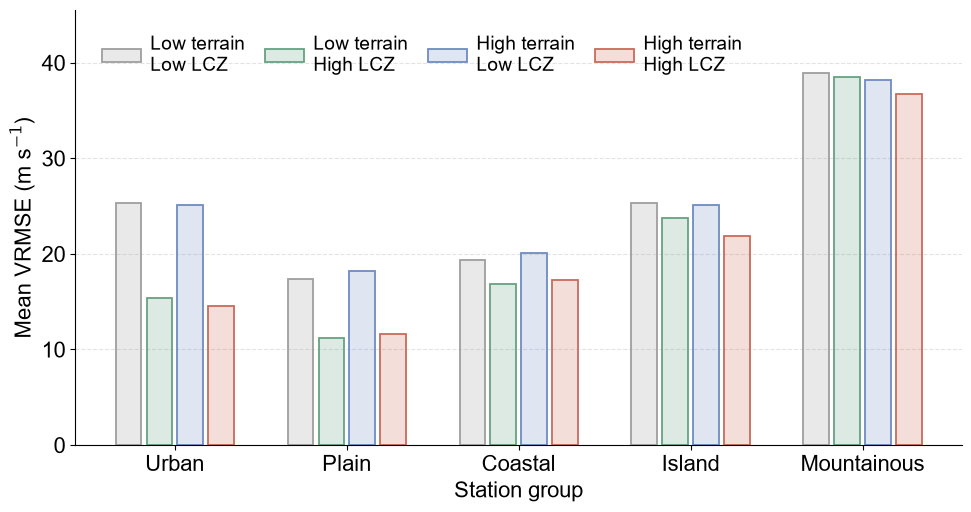

Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_group_mean_ragasa_20250923-19_to_20250924-01_24h_surface_cases.tif


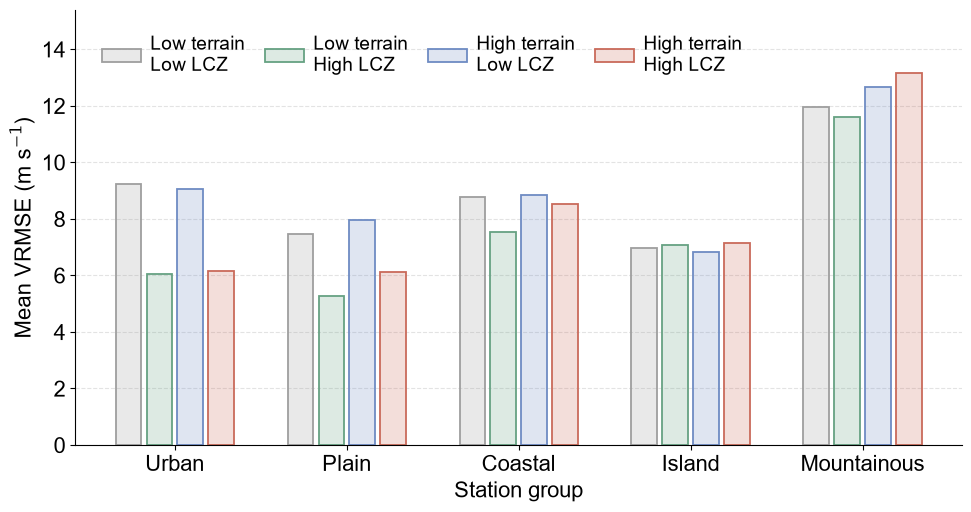

Saved: E:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig6\output\vrmse_group_mean_yagi_20240905-09_to_20240905-15_24h_surface_cases.tif
Validated two TIFF figures, four CSV files, 361-minute windows, and storm-specific 23-station groups.


[WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_group_mean_ragasa_20250923-19_to_20250924-01_24h_surface_cases.tif'),
 WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_group_mean_yagi_20240905-09_to_20240905-15_24h_surface_cases.tif'),
 WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_station_by_group_ragasa_20250923-19_to_20250924-01_24h_surface_cases.csv'),
 WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_group_mean_ragasa_20250923-19_to_20250924-01_24h_surface_cases.csv'),
 WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_station_by_group_yagi_20240905-09_to_20240905-15_24h_surface_cases.csv'),
 WindowsPath('E:/BaiduSyncdisk/Code/06_AI_WRF_UCM/Figs/Fig6/output/vrmse_group_mean_yagi_20240905-09_to_20240905-15_24h_surface_cases.csv')]

In [4]:
def plot_group_means(result: dict) -> Path:
    group_names = result["group_names_en"]
    group_df = result["group_df"]
    x = np.arange(len(group_names), dtype=float)
    n_cases = len(CASE_ORDER)
    bar_spacing = min(0.18, 0.78 / n_cases)
    bar_width = 0.82 * bar_spacing

    fig, ax = plt.subplots(figsize=(10.0, 5.4))
    for case_index, case_key in enumerate(CASE_ORDER):
        values = (group_df.loc[group_df["case_key"] == case_key]
                  .set_index("group_en").reindex(group_names)["mean_vrmse"].to_numpy(dtype=float))
        ax.bar(
            x + (case_index - (n_cases - 1) / 2) * bar_spacing, values, width=bar_width,
            facecolor=mpl.colors.to_rgba(CASE_META[case_key]["color"], 0.22),
            edgecolor=CASE_META[case_key]["color"], linewidth=1.3,
            label=CASE_META[case_key]["label"],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(group_names)
    ax.set_xlabel("Station group")
    ax.set_ylabel("Mean VRMSE (m s$^{-1}$)")
    ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    y_max = group_df["mean_vrmse"].max()
    ax.set_ylim(0.0, y_max * 1.17)
    ax.legend(frameon=False, ncol=n_cases, loc="upper left", bbox_to_anchor=(0.01, 0.985), fontsize=14, columnspacing=1.0, handletextpad=0.5)
    fig.tight_layout()

    output_path = OUTPUT_DIR / f"vrmse_group_mean_{result['output_tag']}.tif"
    save_tiff(fig, output_path)
    plt.show()
    plt.close(fig)
    print("Saved:", output_path)
    return output_path


generated_figures = [plot_group_means(result) for result in storm_results.values()]
generated_outputs = [*generated_figures, *generated_csvs]
if len(generated_figures) != 2 or len(generated_csvs) != 4 or len(generated_outputs) != 6:
    raise RuntimeError("Expected two TIFF figures and four CSV outputs")
for path in generated_outputs:
    if not path.is_file() or path.stat().st_size == 0:
        raise RuntimeError(f"Missing or empty output: {path}")

print("Validated two TIFF figures, four CSV files, 361-minute windows, and storm-specific 23-station groups.")
generated_outputs